# P1 · Reduce along the right axis

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.7 · Reduce along the right axis

A reduction combines the selected axis. keepdim preserves a singleton axis for a later broadcast.

**Prerequisites:** Elementwise operations and broadcasting

**Predict:** Which variance correction matches LayerNorm?

**Mental model:** Taking a mean is incomplete until you say which values are averaged together. A tensor can contain several axes with different meanings.

### Why this operation exists

Taking a mean is incomplete until you say which values are averaged together. A tensor can contain several axes with different meanings.

Averaging features within each token produces one value per token. Averaging all entries instead produces one scalar for the entire tensor.

Keepdim retains the reduced axis at length one. That makes it align correctly when a result is subtracted from the original tensor.

Max and argmax answer different questions: the largest value versus the index where a largest value appears. An index can later identify a predicted token.

Trace the remaining axes after each reduction. This prepares normalization, loss averaging and accuracy measurement.

### Follow the values

The two token vectors are two, zero, one and five, three, four. Each has three features.

Their feature means are one and four. Keeping the final axis produces a two-by-one result.

Subtract the matching mean from each vector. Both centered vectors become one, minus one and zero.

The population variance is two thirds for each vector. Correction zero divides the squared deviations by the number of features.

The whole tensor mean is 2.5, while feature-wise means answer a different question. Adding ten to every input shifts the means but leaves centered vectors and variances unchanged.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.tensor([[2.,0.,1.],[5.,3.,4.]]) + (10 if change else 0)
show("Two token vectors", x)
means = x.mean(dim=-1, keepdim=True)
show("One mean per token [2,1]", means)
show("Centered vectors", x-means)
show("Population variance per token", x.var(dim=-1, correction=0))
show("Different questions", {"whole tensor mean": x.mean().item(), "feature means": x.mean(dim=0).tolist(), "largest feature index": x.argmax(dim=-1).tolist()})

Two token vectors: [[2.0, 0.0, 1.0], [5.0, 3.0, 4.0]]
  shape [2, 3] · torch.float32 · cpu
One mean per token [2,1]: [[1.0], [4.0]]
  shape [2, 1] · torch.float32 · cpu
Centered vectors: [[1.0, -1.0, 0.0], [1.0, -1.0, 0.0]]
  shape [2, 3] · torch.float32 · cpu
Population variance per token: [0.6666666865348816, 0.6666666865348816]
  shape [2] · torch.float32 · cpu
Different questions: {"whole tensor mean": 2.5, "feature means": [3.5, 1.5, 2.5], "largest feature index": [0, 0]}


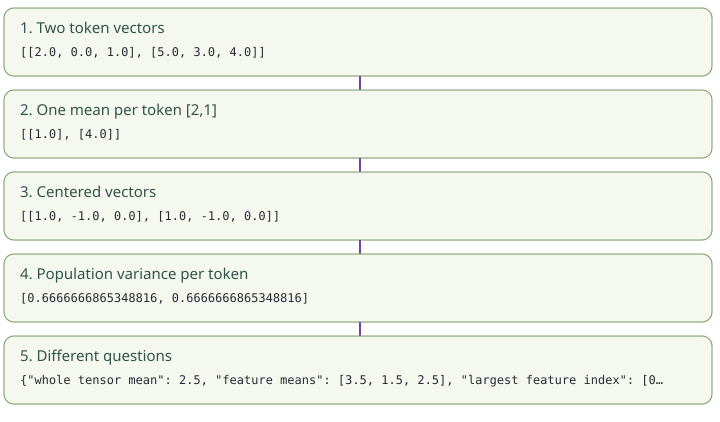

In [4]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

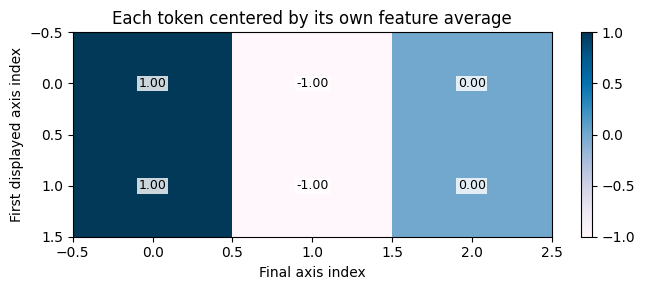

In [5]:
image = (x-means).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Each token centered by its own feature average'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### Read the implementation

Use dim minus one to reduce the feature axis in this example. Keepdim makes its output broadcastable back across that axis.

Mean without dim combines all entries. That is appropriate only when the intended weighting really gives every included entry equal weight.

Variance uses a correction setting. LayerNorm's variance uses correction zero, which differs from torch var's default sample correction.

Argmax returns indices. If scores are tied, do not infer a unique preferred class from equal values; inspect the API's tie behavior when it matters.

Boolean comparisons can be reduced to counts or mean accuracy after conversion. Keep the denominator aligned with the set of valid targets.

### Change one thing

**Add ten to all features**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.tensor([[2.,0.,1.],[5.,3.,4.]]) + (10 if change else 0)
show("Two token vectors", x)
means = x.mean(dim=-1, keepdim=True)
show("One mean per token [2,1]", means)
show("Centered vectors", x-means)
show("Population variance per token", x.var(dim=-1, correction=0))
show("Different questions", {"whole tensor mean": x.mean().item(), "feature means": x.mean(dim=0).tolist(), "largest feature index": x.argmax(dim=-1).tolist()})

Two token vectors: [[12.0, 10.0, 11.0], [15.0, 13.0, 14.0]]
  shape [2, 3] · torch.float32 · cpu
One mean per token [2,1]: [[11.0], [14.0]]
  shape [2, 1] · torch.float32 · cpu
Centered vectors: [[1.0, -1.0, 0.0], [1.0, -1.0, 0.0]]
  shape [2, 3] · torch.float32 · cpu
Population variance per token: [0.6666666865348816, 0.6666666865348816]
  shape [2] · torch.float32 · cpu
Different questions: {"whole tensor mean": 12.5, "feature means": [13.5, 11.5, 12.5], "largest feature index": [0, 0]}


### A useful distinction

torch.var defaults to a sample correction; LayerNorm uses population variance over its normalized axes.

### ✋ Your turn

Center each token in [[1,3],[10,14]] using its own feature mean; put the nested list in answer.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[-1,1],[-2,2]], 'torch.var defaults to a sample correction; LayerNorm uses population variance over its normalized axes.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
x = torch.tensor([[1.,3.],[10.,14.]])
answer = (x - x.mean(-1, keepdim=True)).tolist()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == [[-1,1],[-2,2]], 'torch.var defaults to a sample correction; LayerNorm uses population variance over its normalized axes.'
    print("✓ right:", answer)

✓ right: [[-1.0, 1.0], [-2.0, 2.0]]


### Reconnect to the transformer

LayerNorm computes statistics across the feature axes it is configured to normalize. It does not automatically average across the batch.

Cross-entropy can return a loss for each target or reduce those losses. Padding changes which target positions should contribute to an average.

Accuracy compares predicted IDs with target IDs and counts matches. It is a different measurement from the probabilities used by cross-entropy.

Averaging batch averages is only correct when their effective counts are equal or appropriately weighted. The training unit develops this aggregation rule.

Next, learn a calculation that combines two axes through products: matrix multiplication.

```python
mean = x.mean(dim=-1, keepdim=True)
variance = x.var(dim=-1, correction=0, keepdim=True)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which variance correction matches LayerNorm?

<details><summary>Check your explanation</summary>

0. torch.var defaults to a sample correction; LayerNorm uses population variance over its normalized axes.

</details>